In [25]:
from langgraph.graph import StateGraph, START, END
from langgraph.store.memory import InMemoryStore
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.base import BaseStore
from langchain_ollama import ChatOllama
from typing_extensions import TypedDict
from pydantic import BaseModel, Field
from typing import List, Annotated, Literal
import operator

In [26]:
class DunkState(BaseModel):
    hp: int = Field(..., description="Current health points of Dunk")
    armor_durability: int = Field(..., description="Durability of Dunk's armor")
    armor_damage_description: str = Field(..., description="Description of the damage to Dunk's armor")

class JoustState(TypedDict):
    opponent_name: str
    opponent_hp: int
    opponent_armor_durability: int
    opponent_weakness: str
    strategy: str
    dunk_vitals: DunkState
    joust_history: Annotated[List[str], operator.add]
    curr_rounds: int
    max_rounds: int

In [27]:
llm = ChatOllama(model="llama3")

In [28]:
def edd_repair(state: JoustState) -> dict:
    armor_damage_desc = state["dunk_vitals"].armor_damage_description
    prompt = f"""Dunk's armor has sustained the following damage: {armor_damage_desc}.
Edd the Repairer is a skilled blacksmith known for his expertise in repairing armor. Based on the damage description, Edd will provide a detailed repair plan, including the materials needed, the steps to be taken, and the estimated time for completion. Edd's advice should be practical and short.
    Rules:
    1. Response should be concise and to the point, without unnecessary elaboration.
    2. Generate the estimated time required to complete the repairs in hours, and include it in the response.
"""
    # FIX: Changed to modern .invoke syntax
    response = llm.invoke([SystemMessage(content=prompt)])
    print(response.content)
    
    # FIX: Maintain Pydantic object integrity and preserve current HP
    updated_vitals = DunkState(
        hp=state["dunk_vitals"].hp,
        armor_durability=100,
        armor_damage_description="No damage"
    )
    return {"dunk_vitals": updated_vitals}

In [29]:
sub_g = StateGraph(JoustState)
sub_g.add_node("edd_repair", edd_repair)
sub_g.add_edge(START, "edd_repair")
sub_g.add_edge("edd_repair", END)

egg_repair = sub_g.compile() # This is your compiled subgraph node!

In [ ]:
SYSTEM_PROMPT = """You are the strategist for Ser Duncan the Tall, a legendary knight preparing for a jousting tournament. Your task is to analyze incoming intelligence about his opponents and devise tactics to ensure his victory. You will receive detailed reports on each opponent's past performance in jousts. Use this information to recommend specific strategies for Dunk to exploit his opponents' vulnerabilities while maximizing his own strengths.There might be chances when no past encounters are found for an opponent. In such cases, acknowledge the lack of information and suggest general strategies that Dunk can employ to adapt to any opponent's style. Always prioritize Dunk's safety and the likelihood of victory in your recommendations.

Opponent history - {opponent_history}
"""

def recall_tactics(state: JoustState, store: BaseStore, config: RunnableConfig):
    user_id = config['configurable']['user_id']
    namespace = config['configurable']['namespace']
    items = store.search(namespace, user_id)
    if items:
        opponent_history = "\n".join(f"- {item.value.get('data', '')}" for item in items)
    else:
        opponent_history = "No prior encounters found."
    system_message = SystemMessage(content=SYSTEM_PROMPT.format(opponent_history=opponent_history))
    response = llm.invoke(system_message)
    return {'strategy': response.content}

def joust_round(state: JoustState)-> dict:
    SYSTEM_PROMPT = """You are the strategist for Ser Duncan the Tall, a legendary knight preparing for a jousting tournament. Based on the current strategy and the vitals of Dunk against random combat variables and predict the hitpoints Dunk would lose in this round and durability Dunk's armor would lose. Always prioritize Dunk's safety and the likelihood of victory in your recommendations.
    Rules:
    1. Make sure your points should have the negative sign for example -20 hp, -10 durability.
    2. If the opponent's strategy is "aim for the head" and Dunk's hp is above 50, Dunk loses 30 hp and 20 durability.
    3. If the opponent's strategy is "aim for the head" and Dunk's hp is 50 or below, Dunk loses 50 hp and 40 durability.
    4. If the opponent's strategy is "aim for the legs" and Dunk's armor durability is above 30, Dunk loses 20 hp and 10 durability.
    5. If the opponent's strategy is "aim for the legs" and Dunk's armor durability is 30 or below, Dunk loses 40 hp and 20 durability.

    Current strategy - {strategy}
    Dunk's vitals - {dunk_vitals}
    """
    updated_dunk_vitals = llm.with_structured_output(DunkState).invoke(SystemMessage(content=SYSTEM_PROMPT.format(strategy=state['strategy'], dunk_vitals=state['dunk_vitals'])))

    del_hp, del_armor = updated_dunk_vitals.hp, updated_dunk_vitals.armor_durability

    p = f"""Opponent used strategy '{state['strategy']}' resulting in Dunk losing {-del_hp} hp and {-del_armor} durability. Your task is to summarize the current joust round in one sentence . Also include the conclusions from the past rounds if any.
    Past rounds summary - {state['joust_history']}
    """
    joust_summary = llm.invoke([
        SystemMessage(content=p)
    ])

    new_dunk_hp = state['dunk_vitals'].hp + del_hp
    new_dunk_armor = state['dunk_vitals'].armor_durability + del_armor

    return { "dunk_vitals": DunkState(hp=new_dunk_hp, armor_durability=new_dunk_armor, armor_damage_description=updated_dunk_vitals.armor_damage_description) , "joust_history": [joust_summary.content], "curr_rounds": state['curr_rounds'] + 1 }

def router(state: JoustState):
    """Router function to determine the next step in the joust based on the current state."""
    return {}
def router_dec(state: JoustState):
    if state['opponent_hp'] <= 0 or state['curr_rounds'] >= state['max_rounds']:
        return "memorize_outcome"
    elif state['dunk_vitals'].armor_durability <= 20:
        return "egg_shell"
    else:
        return "joust_round"

def memorize_outcome(state: JoustState, store: BaseStore, config: RunnableConfig):
    user_id = config['configurable']['user_id']
    namespace = config['configurable']['namespace']
    joust_history = "\n".join(f"- {item}" for item in state['joust_history'])
    prompt = f"""Ser Duncan the Tall has completed the joust against {state['opponent_name']}. The joust history is as follows:
    {joust_history} your task is to create a concise report about the opponent's weakness and the strategy used to defeat them if they were defeated or the strategy used by the opponent to defeat Dunk if Dunk was defeated. This report should be useful for future reference in jousts against the same opponent or similar opponents. Always prioritize providing actionable insights that can be applied in future encounters.
    Rules:
    1. The report should be concise, ideally no more than 5 sentences or total of 200 words.
    """
    report = llm.invoke(SystemMessage(content=prompt))
    store.put(namespace,user_id, {"data": report.content})
    return {"joust_history": [report.content]}



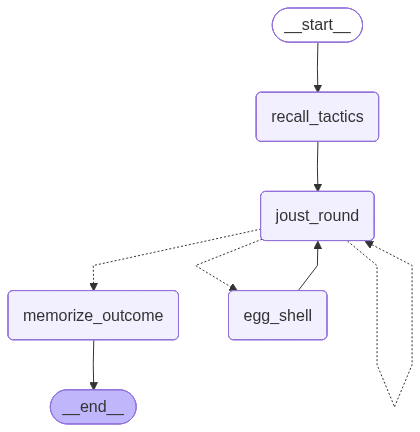

In [31]:
checkpointer = InMemorySaver()
store = InMemoryStore()
graph = StateGraph(JoustState)

# Nodes
graph.add_node("recall_tactics", recall_tactics)
graph.add_node("joust_round", joust_round)
graph.add_node("memorize_outcome", memorize_outcome)
graph.add_node("egg_shell", egg_repair) # Passing the compiled subgraph here

# Edges
graph.add_edge(START, "recall_tactics")
graph.add_edge("recall_tactics", "joust_round")

# Routing directly out of joust_round to eliminate the unnecessary pass-through node
graph.add_conditional_edges("joust_round", router_dec, {
    "memorize_outcome": "memorize_outcome",
    "egg_shell": "egg_shell",
    "joust_round": "joust_round"
})

graph.add_edge("egg_shell", "joust_round")
graph.add_edge("memorize_outcome", END)

flow = graph.compile(store=store, checkpointer=checkpointer)
flow